# Report 5 — Plots

Generates all figures for R5 by reading saved per-fold CSVs and confusion matrices from Drive. Runs independently of the training notebooks — safe to use while per-window training is still in progress (uses only completed folds).

**Figures produced:**
1. Per-subject balanced accuracy — best config, both protocols
2. Confusion matrix — best config, both protocols
3. Plain vs DANN vs MMD comparison — bar chart per protocol
4. R4 vs R5 comparison — did reliability + dual net help?
5. Reliability weights distribution — which subjects got up/down-weighted
6. Trajectory chart — R2 → R3 → R4 → R5 vs HEDN

All plots saved to `results/report5_plots/` on Drive.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

RESULTS_PW = Path(PROJECT_ROOT) / 'results/report5_perwindow'
RESULTS_PT = Path(PROJECT_ROOT) / 'results/report5_pertrial'
CKPT_PW = Path(PROJECT_ROOT) / 'checkpoints/report5_perwindow'
CKPT_PT = Path(PROJECT_ROOT) / 'checkpoints/report5_pertrial'

PLOTS_DIR = Path(PROJECT_ROOT) / 'results/report5_plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load results from both notebooks
Works with partial results — if per-window is still running, uses whatever folds are completed.

In [3]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix

def load_from_checkpoints(ckpt_dir, tasks, variants):
    """Load fold results directly from checkpoint pickle files.
    Works even if aggregation cells never ran."""
    results = {}
    for task in tasks:
        for variant in variants:
            key = (task, variant)
            path = ckpt_dir / f'{task}_{variant}_folds.pkl'
            if path.exists():
                with open(path, 'rb') as f:
                    results[key] = pickle.load(f)
    return results

TASKS = ['valence', 'arousal', '3class']
VARIANTS = ['plain', 'dann', 'mmd']

RESULTS_PT_ALL = load_from_checkpoints(CKPT_PT, TASKS, VARIANTS)
RESULTS_PW_ALL = load_from_checkpoints(CKPT_PW, TASKS, VARIANTS)

print('Per-trial configurations loaded:')
for k, v in RESULTS_PT_ALL.items():
    print(f'  {k}: {len(v)} folds')
print('\nPer-window configurations loaded:')
for k, v in RESULTS_PW_ALL.items():
    print(f'  {k}: {len(v)} folds')

Per-trial configurations loaded:
  ('valence', 'plain'): 32 folds
  ('valence', 'dann'): 32 folds
  ('valence', 'mmd'): 32 folds
  ('arousal', 'plain'): 32 folds
  ('arousal', 'dann'): 32 folds
  ('arousal', 'mmd'): 32 folds
  ('3class', 'plain'): 32 folds
  ('3class', 'dann'): 32 folds
  ('3class', 'mmd'): 32 folds

Per-window configurations loaded:
  ('valence', 'plain'): 32 folds
  ('valence', 'dann'): 32 folds
  ('valence', 'mmd'): 32 folds
  ('arousal', 'plain'): 32 folds
  ('arousal', 'dann'): 32 folds
  ('arousal', 'mmd'): 32 folds
  ('3class', 'plain'): 32 folds
  ('3class', 'dann'): 32 folds
  ('3class', 'mmd'): 32 folds


In [4]:
def aggregate_from_folds(fold_results, n_classes):
    per_fold, all_true, all_pred = [], [], []
    for sid, r in sorted(fold_results.items()):
        y_true, y_pred = r['y_true'], r['y_pred']
        all_true.append(y_true); all_pred.append(y_pred)
        per_fold.append({
            'sid': r['sid'],
            'acc': 100 * accuracy_score(y_true, y_pred),
            'bal': 100 * balanced_accuracy_score(y_true, y_pred),
        })
    df = pd.DataFrame(per_fold)
    if all_true:
        y_true_all = np.concatenate(all_true)
        y_pred_all = np.concatenate(all_pred)
        cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(n_classes)))
    else:
        cm = np.zeros((n_classes, n_classes))
    return df, cm

def n_classes_of(task):
    return 3 if task == '3class' else 2

# Build summary table from checkpoints
def build_summary(results_dict, protocol_label):
    rows = []
    per_fold_all, cms_all = {}, {}
    for (task, variant), fr in results_dict.items():
        if not fr: continue
        df, cm = aggregate_from_folds(fr, n_classes_of(task))
        per_fold_all[(task, variant)] = df
        cms_all[(task, variant)] = cm
        rows.append({
            'protocol': protocol_label,
            'task': task, 'variant': variant,
            'bal_mean': df['bal'].mean(),
            'bal_std':  df['bal'].std(),
            'n_folds':  len(df),
        })
    return pd.DataFrame(rows), per_fold_all, cms_all

SUMMARY_PT, PF_PT, CM_PT = build_summary(RESULTS_PT_ALL, 'per-trial')
SUMMARY_PW, PF_PW, CM_PW = build_summary(RESULTS_PW_ALL, 'per-window')

SUMMARY = pd.concat([SUMMARY_PT, SUMMARY_PW], ignore_index=True)
print(SUMMARY.to_string(index=False))

  protocol    task variant  bal_mean  bal_std  n_folds
 per-trial valence   plain 62.932367 9.162431       32
 per-trial valence    dann 64.260245 8.544423       32
 per-trial valence     mmd 64.560559 8.807692       32
 per-trial arousal   plain 64.811278 7.994135       32
 per-trial arousal    dann 64.783511 8.962465       32
 per-trial arousal     mmd 62.979921 7.631758       32
 per-trial  3class   plain 46.041780 7.765977       32
 per-trial  3class    dann 46.974711 8.402182       32
 per-trial  3class     mmd 46.880557 8.381453       32
per-window valence   plain 55.859606 5.202986       32
per-window valence    dann 53.773797 3.984854       32
per-window valence     mmd 55.690297 5.645070       32
per-window arousal   plain 54.296331 3.926931       32
per-window arousal    dann 53.889822 3.972744       32
per-window arousal     mmd 51.362294 3.077761       32
per-window  3class   plain 38.076922 3.776291       32
per-window  3class    dann 37.012518 4.478077       32
per-window

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 3. Figure — Plain vs DANN vs MMD across tasks (per-trial)

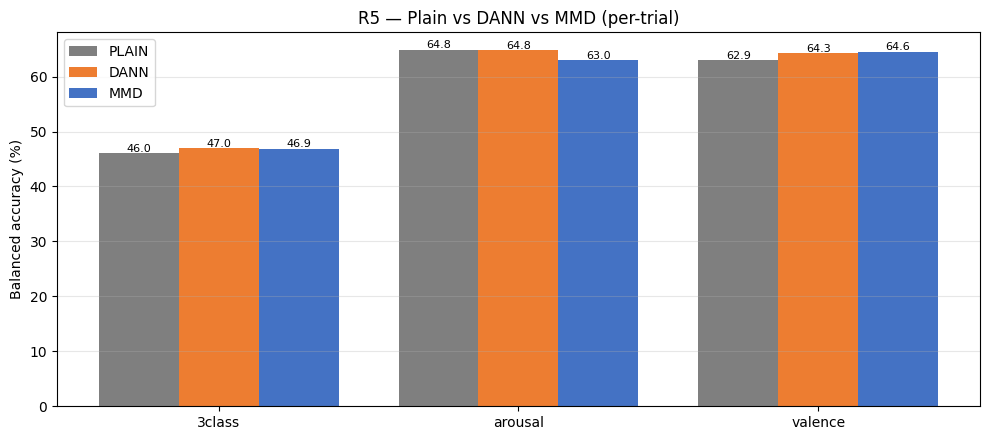

In [5]:
def plot_variant_comparison(summary_df, protocol, save_path):
    df = summary_df[summary_df['protocol'] == protocol].copy()
    if df.empty:
        print(f'No data for {protocol}')
        return
    pivot = df.pivot_table(index='task', columns='variant', values='bal_mean')
    # Reindex if all variants present
    present = [v for v in ['plain', 'dann', 'mmd'] if v in pivot.columns]
    pivot = pivot[present]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    tasks = pivot.index.tolist()
    x = np.arange(len(tasks))
    w = 0.8 / len(present)
    colors = {'plain': '#7f7f7f', 'dann': '#ED7D31', 'mmd': '#4472C4'}
    for i, v in enumerate(present):
        offset = (i - (len(present) - 1) / 2) * w
        bars = ax.bar(x + offset, pivot[v], w, label=v.upper(), color=colors[v])
        for b, val in zip(bars, pivot[v]):
            ax.text(b.get_x() + b.get_width()/2, val + 0.3,
                    f'{val:.1f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(tasks)
    ax.set_ylabel('Balanced accuracy (%)')
    ax.set_title(f'R5 — Plain vs DANN vs MMD ({protocol})')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

plot_variant_comparison(SUMMARY, 'per-trial', PLOTS_DIR / 'r5_variants_pertrial.png')

## 4. Figure — Plain vs DANN vs MMD across tasks (per-window)
Will show partial results if per-window is still running.

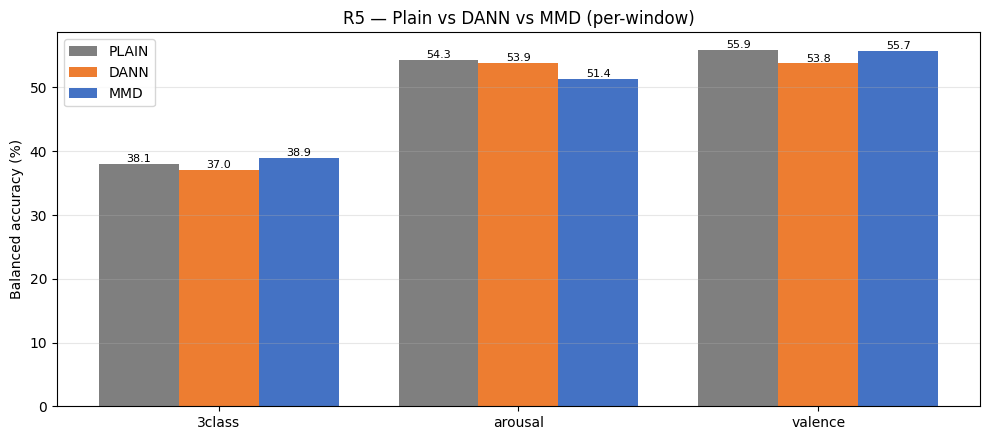

In [6]:
plot_variant_comparison(SUMMARY, 'per-window', PLOTS_DIR / 'r5_variants_perwindow.png')

## 5. Figure — Per-subject balanced accuracy (best config)

Best per-trial config: ('arousal', 'plain')


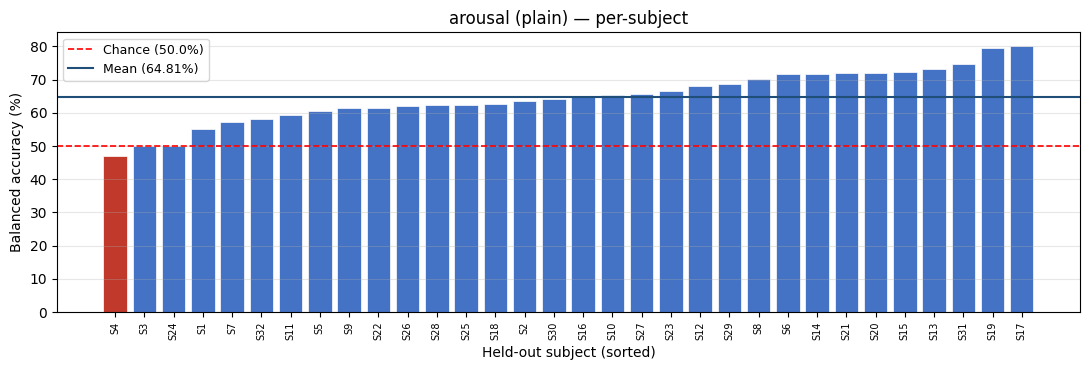

Best per-window config: ('valence', 'plain')


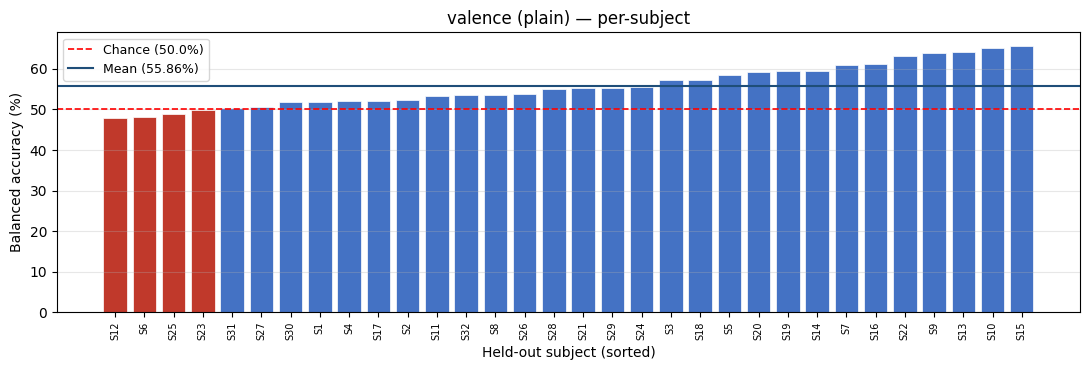

In [7]:
def plot_per_subject(per_fold_dict, task_variant, task, save_path):
    if task_variant not in per_fold_dict:
        print(f'No data for {task_variant}')
        return
    df = per_fold_dict[task_variant].sort_values('bal').reset_index(drop=True)
    chance = 100.0 / n_classes_of(task)
    mean_bal = df['bal'].mean()
    fig, ax = plt.subplots(figsize=(11, 3.8))
    colors = ['#c0392b' if v < chance else '#4472C4' for v in df['bal']]
    ax.bar(range(len(df)), df['bal'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(chance, color='red', linestyle='--', linewidth=1.2, label=f'Chance ({chance:.1f}%)')
    ax.axhline(mean_bal, color='#1F4E79', linewidth=1.5, label=f'Mean ({mean_bal:.2f}%)')
    ax.set_xlabel('Held-out subject (sorted)'); ax.set_ylabel('Balanced accuracy (%)')
    ax.set_title(f'{task_variant[0]} ({task_variant[1]}) — per-subject')
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([f'S{int(s)}' for s in df['sid']], rotation=90, fontsize=7)
    ax.legend(loc='upper left', fontsize=9); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

# Identify best config per protocol
def best_config(summary_df, protocol):
    sub = summary_df[summary_df['protocol'] == protocol]
    if sub.empty: return None
    best = sub.loc[sub['bal_mean'].idxmax()]
    return (best['task'], best['variant'])

best_pt = best_config(SUMMARY, 'per-trial')
best_pw = best_config(SUMMARY, 'per-window')

if best_pt:
    print(f'Best per-trial config: {best_pt}')
    plot_per_subject(PF_PT, best_pt, best_pt[0], PLOTS_DIR / f'r5_persub_pertrial_{best_pt[0]}_{best_pt[1]}.png')

if best_pw:
    print(f'Best per-window config: {best_pw}')
    plot_per_subject(PF_PW, best_pw, best_pw[0], PLOTS_DIR / f'r5_persub_perwindow_{best_pw[0]}_{best_pw[1]}.png')

## 6. Figure — Confusion matrix for best configs

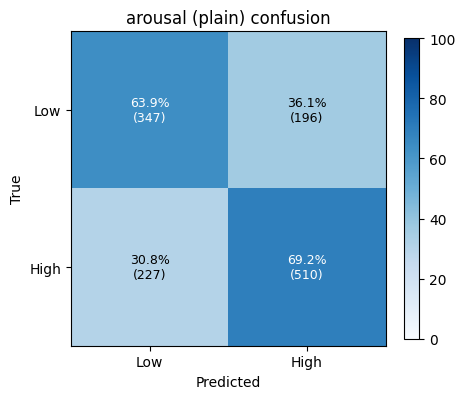

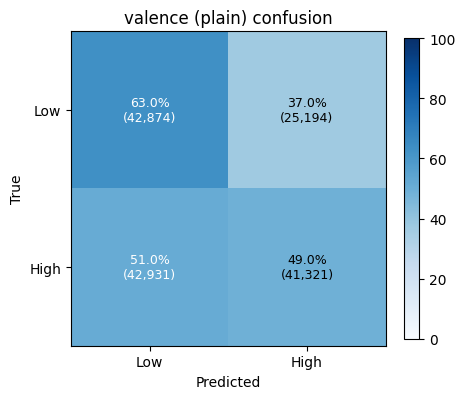

In [8]:
def plot_confusion(cm, task, task_variant, save_path):
    cm = cm.astype(float)
    if cm.sum() == 0:
        print(f'No data for {task_variant}')
        return
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-10) * 100
    n = cm.shape[0]
    names = (['Low', 'High'] if task in ('valence', 'arousal') else ['Neg', 'Neu', 'Pos'])
    fig, ax = plt.subplots(figsize=(4.8, 4.1))
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(n):
        for j in range(n):
            c = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i, j]:.1f}%\n({int(cm[i, j]):,})',
                    ha='center', va='center', color=c, fontsize=9)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{task_variant[0]} ({task_variant[1]}) confusion')
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

if best_pt and best_pt in CM_PT:
    plot_confusion(CM_PT[best_pt], best_pt[0], best_pt, PLOTS_DIR / f'r5_cm_pertrial_{best_pt[0]}_{best_pt[1]}.png')

if best_pw and best_pw in CM_PW:
    plot_confusion(CM_PW[best_pw], best_pw[0], best_pw, PLOTS_DIR / f'r5_cm_perwindow_{best_pw[0]}_{best_pw[1]}.png')

## 7. Figure — R4 vs R5 comparison (did the techniques help?)

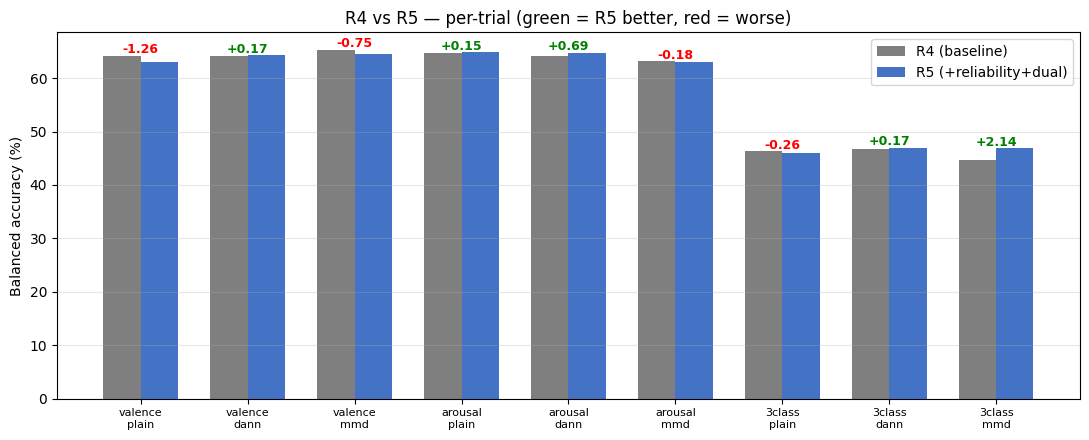

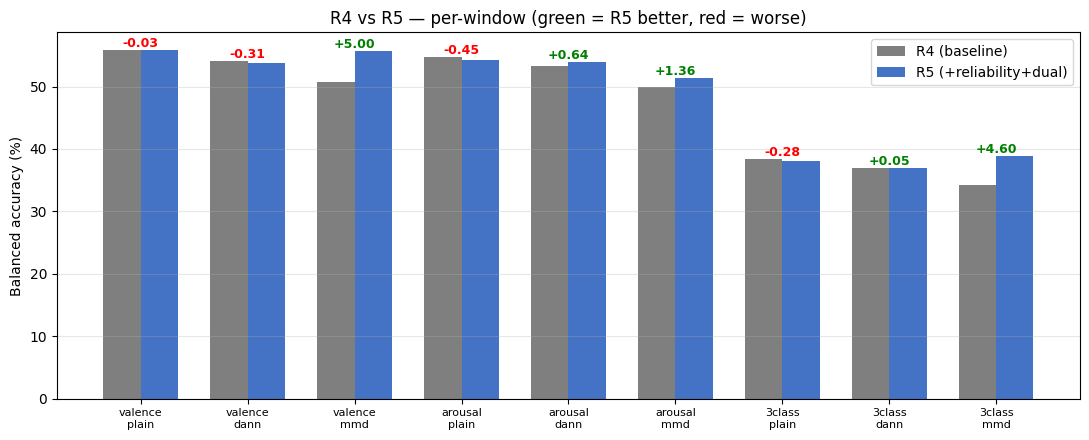

In [9]:
# R4 results (hard-coded from your R4B run — the previous best)
R4B_PERTRIAL = {
    ('valence', 'plain'): 64.19,
    ('valence', 'dann'):  64.09,
    ('valence', 'mmd'):   65.31,
    ('arousal', 'plain'): 64.66,
    ('arousal', 'dann'):  64.09,
    ('arousal', 'mmd'):   63.16,
    ('3class',  'plain'): 46.30,
    ('3class',  'dann'):  46.80,
    ('3class',  'mmd'):   44.74,
}
R4_PERWINDOW = {
    ('valence', 'plain'): 55.89,
    ('valence', 'dann'):  54.08,
    ('valence', 'mmd'):   50.69,
    ('arousal', 'plain'): 54.75,
    ('arousal', 'dann'):  53.25,
    ('arousal', 'mmd'):   50.00,
    ('3class',  'plain'): 38.36,
    ('3class',  'dann'):  36.96,
    ('3class',  'mmd'):   34.30,
}

def plot_r4_vs_r5(summary_df, r4_dict, protocol, save_path):
    r5 = summary_df[summary_df['protocol'] == protocol]
    if r5.empty:
        print(f'No R5 data for {protocol}')
        return
    rows = []
    for _, row in r5.iterrows():
        key = (row['task'], row['variant'])
        r4_bal = r4_dict.get(key)
        if r4_bal is not None:
            rows.append({
                'task_variant': f'{row["task"]}\n{row["variant"]}',
                'R4': r4_bal,
                'R5': row['bal_mean'],
                'delta': row['bal_mean'] - r4_bal,
            })
    if not rows:
        print(f'No matching R4 baseline for {protocol}')
        return
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(df)); w = 0.35
    ax.bar(x - w/2, df['R4'], w, label='R4 (baseline)',   color='#7f7f7f')
    ax.bar(x + w/2, df['R5'], w, label='R5 (+reliability+dual)', color='#4472C4')
    for i, row in df.iterrows():
        color = 'green' if row['delta'] > 0 else 'red'
        ax.text(i, max(row['R4'], row['R5']) + 0.5, f'{row["delta"]:+.2f}',
                ha='center', fontsize=9, color=color, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(df['task_variant'], fontsize=8)
    ax.set_ylabel('Balanced accuracy (%)')
    ax.set_title(f'R4 vs R5 — {protocol} (green = R5 better, red = worse)')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

plot_r4_vs_r5(SUMMARY, R4B_PERTRIAL, 'per-trial', PLOTS_DIR / 'r4_vs_r5_pertrial.png')
plot_r4_vs_r5(SUMMARY, R4_PERWINDOW, 'per-window', PLOTS_DIR / 'r4_vs_r5_perwindow.png')

## 8. Figure — Reliability weights distribution
Shows which training subjects got upweighted (generalize well) and which got downweighted (below-chance individuals).

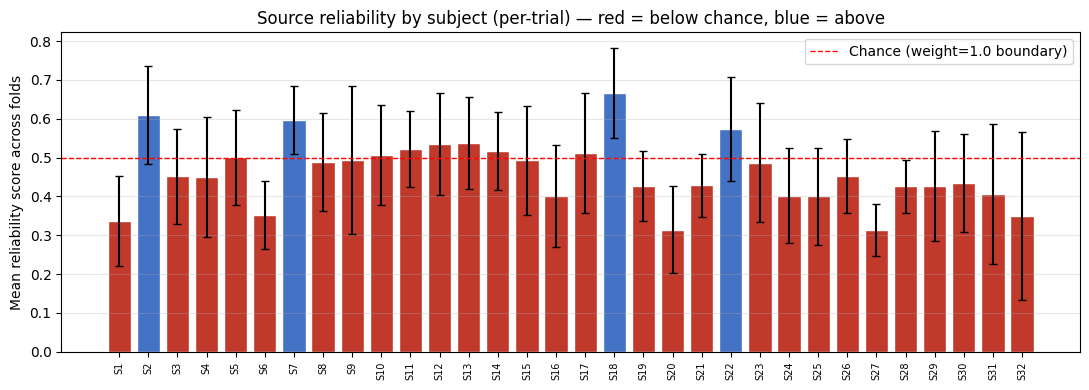

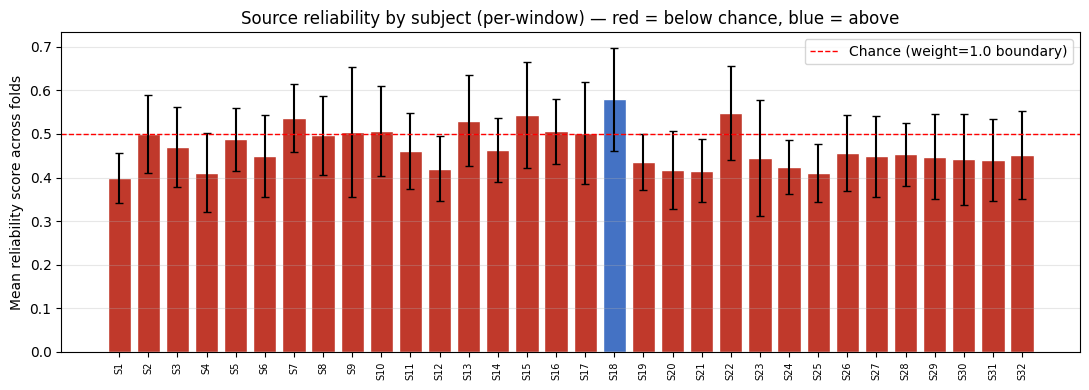

In [10]:
def plot_reliability_weights(results_dict, protocol_label, save_path):
    all_weights = {}
    for (task, variant), fr in results_dict.items():
        for sid, r in fr.items():
            if 'reliability' in r:
                for sub_id, rel in r['reliability'].items():
                    all_weights.setdefault(sub_id, []).append(rel)
    if not all_weights:
        print(f'No reliability data saved for {protocol_label}')
        return
    subs_sorted = sorted(all_weights.keys())
    means = [np.mean(all_weights[s]) for s in subs_sorted]
    stds  = [np.std(all_weights[s]) for s in subs_sorted]
    fig, ax = plt.subplots(figsize=(11, 4))
    colors = ['#c0392b' if m < 0.55 else '#4472C4' for m in means]
    ax.bar(range(len(subs_sorted)), means, yerr=stds, color=colors,
           edgecolor='white', capsize=3)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Chance (weight=1.0 boundary)')
    ax.set_xticks(range(len(subs_sorted)))
    ax.set_xticklabels([f'S{int(s)}' for s in subs_sorted], rotation=90, fontsize=7)
    ax.set_ylabel('Mean reliability score across folds')
    ax.set_title(f'Source reliability by subject ({protocol_label}) — red = below chance, blue = above')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

plot_reliability_weights(RESULTS_PT_ALL, 'per-trial', PLOTS_DIR / 'r5_reliability_pertrial.png')
plot_reliability_weights(RESULTS_PW_ALL, 'per-window', PLOTS_DIR / 'r5_reliability_perwindow.png')

## 9. Figure — Project trajectory (R2 → R3 → R4 → R5 vs HEDN)

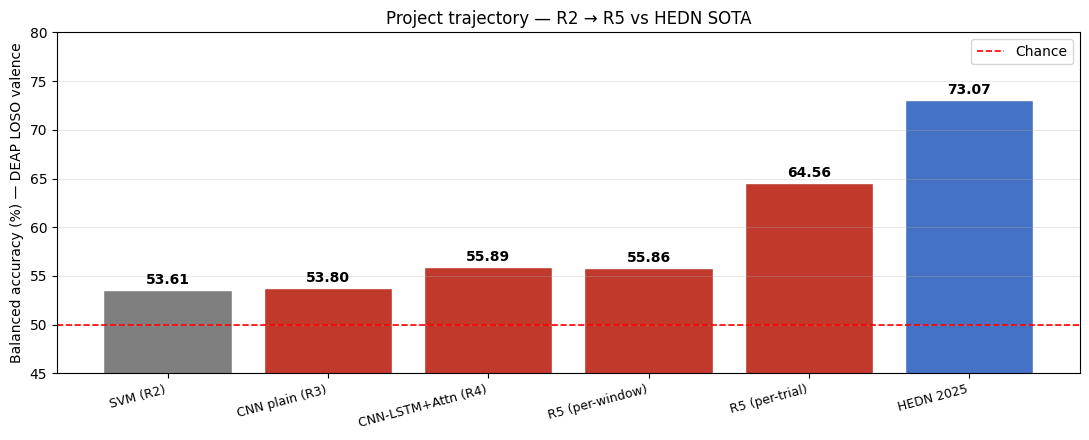

In [11]:
# Full project trajectory — use best per-window valence for consistency
best_r5_pw = None
if 'per-window' in SUMMARY['protocol'].values:
    sub = SUMMARY[(SUMMARY['protocol'] == 'per-window') & (SUMMARY['task'] == 'valence')]
    if not sub.empty:
        best_r5_pw = sub['bal_mean'].max()

best_r5_pt = None
if 'per-trial' in SUMMARY['protocol'].values:
    sub = SUMMARY[(SUMMARY['protocol'] == 'per-trial') & (SUMMARY['task'] == 'valence')]
    if not sub.empty:
        best_r5_pt = sub['bal_mean'].max()

labels = ['SVM (R2)', 'CNN plain (R3)', 'CNN-LSTM+Attn (R4)']
values = [53.61, 53.80, 55.89]
colors = ['#7f7f7f', '#c0392b', '#c0392b']

if best_r5_pw is not None:
    labels.append('R5 (per-window)'); values.append(best_r5_pw); colors.append('#c0392b')
if best_r5_pt is not None:
    labels.append('R5 (per-trial)'); values.append(best_r5_pt); colors.append('#c0392b')

labels.append('HEDN 2025'); values.append(73.07); colors.append('#4472C4')

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(labels, values, color=colors, edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Chance')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.6, f'{v:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Balanced accuracy (%) — DEAP LOSO valence')
ax.set_title('Project trajectory — R2 → R5 vs HEDN SOTA')
ax.set_ylim(45, 80)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'trajectory_r2_r5.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Save aggregate summary CSV

In [12]:
SUMMARY.to_csv(PLOTS_DIR / 'r5_summary_full.csv', index=False)
print('All plots and summary saved to:', PLOTS_DIR)

All plots and summary saved to: /content/drive/MyDrive/case_study_2/results/report5_plots
